In [1]:
import pandas as pd

In [2]:
#file_path = r"C:\Users\User\Desktop\2026\2604\20260427_Data tool_20260427111323299\20260427_Data tool_20260427111323299.xlsx"
#file_path = "/Users/yshmbid/Documents/home/github/kosmos/workspace/data/20260427_Data tool_20260427111323299.xlsx"
file_path = "/Users/yshmbid/Documents/home/github/kosmos/workspace/data/20260429_Data tool_20260429154123801.xlsx"
df = pd.read_excel(file_path, engine="openpyxl")
df_raw = df
df = df[['SUBJ_ID', 'BRND_CD', 'BRND_NM_VER', 'BRND_NM_ECT_YN', 'BRND_NM_ECT_CMNT']]

/opt/anaconda3/envs/skala/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [3]:
#df['HOSP_ID'] = df['SUBJ_ID'].apply(lambda x: x.split('-')[0] if isinstance(x, str) and '-' in x else float('nan'))
#df = df[['HOSP_ID'] + [col for col in df.columns if col != 'HOSP_ID']]

df['HOSP_ID'] = df['SUBJ_ID'].apply(lambda x: x.split('-')[0] if isinstance(x, str) and '-' in x else x)
df = df[['HOSP_ID'] + [col for col in df.columns if col != 'HOSP_ID']]

/var/folders/5_/cr0lgx655m7fqg_j4q733qbm0000gn/T/ipykernel_8271/1555521392.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['HOSP_ID'] = df['SUBJ_ID'].apply(lambda x: x.split('-')[0] if isinstance(x, str) and '-' in x else x)


In [4]:
df = df.sort_values('HOSP_ID').reset_index(drop=True)
df['HOSP_ID'].value_counts()

HOSP_ID
S006     120
S001     115
S003     113
S010      91
S002      65
S007      49
S004      48
S012      44
S016      31
S011      28
S023      26
S031      25
S024      24
S005      22
S020      22
S009      20
S018      19
S008      17
S027      17
S014      14
S013      14
S030      12
S021      11
S026       8
S015       8
S025       8
S019       8
S028       8
S017       7
S022       5
S029       4
S032       4
test2      1
test3      1
Name: count, dtype: int64

In [5]:
df['HOSP_ID'].value_counts().sum()

1009

In [6]:
df = df[~df['HOSP_ID'].isin(['test2', 'test3'])]

In [7]:
df

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT
0,S001,S001-001,P008,Oncomine Comprehensive Assay v3,NaN,NaN
1,S001,S001-090,P016,TSO500 ver2.2,NaN,NaN
2,S001,S001-089,P016,TSO500 ver2.2,NaN,NaN
3,S001,S001-087,P016,TSO500 ver2.2,NaN,NaN
4,S001,S001-086,P016,TSO500 ver2.2,NaN,NaN
...,...,...,...,...,...,...
1002,S031,S031-006,P018,ONCOaccuPanel v4.3,NaN,NaN
1003,S032,S032-002,P019,ONCOaccuPanel v4.5,NaN,NaN
1004,S032,S032-003,P016,TSO500 ver2.2,NaN,NaN
1005,S032,S032-004,NaN,NaN,1.0,S032-004_panel(AUH-SCT1?)


In [8]:
brnd_cd_y = df[df['BRND_CD'].notna()]
brnd_cd_n = df[df['BRND_CD'].isna()]

In [9]:
brnd_cd_y

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT
0,S001,S001-001,P008,Oncomine Comprehensive Assay v3,NaN,NaN
1,S001,S001-090,P016,TSO500 ver2.2,NaN,NaN
2,S001,S001-089,P016,TSO500 ver2.2,NaN,NaN
3,S001,S001-087,P016,TSO500 ver2.2,NaN,NaN
4,S001,S001-086,P016,TSO500 ver2.2,NaN,NaN
...,...,...,...,...,...,...
1001,S031,S031-011,P018,ONCOaccuPanel v4.3,NaN,NaN
1002,S031,S031-006,P018,ONCOaccuPanel v4.3,NaN,NaN
1003,S032,S032-002,P019,ONCOaccuPanel v4.5,NaN,NaN
1004,S032,S032-003,P016,TSO500 ver2.2,NaN,NaN


In [10]:
brnd_cd_n

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT
51,S001,S001-099,NaN,NaN,1.0,S001-098_panel
52,S001,S001-098,NaN,NaN,1.0,S001-098_panel
105,S001,S001-041,NaN,NaN,1.0,S001-041_panel
112,S001,S001-033,NaN,NaN,1.0,S001-033_panel
115,S002,S002-047,NaN,NaN,1.0,FIRST-Cancer Panel v3.3
...,...,...,...,...,...,...
931,S026,S026-005,NaN,NaN,1.0,"S026-005, S026-006, S026-007_panel"
932,S026,S026-007,NaN,NaN,1.0,"S026-005, S026-006, S026-007_panel"
982,S031,S031-023,NaN,NaN,1.0,S031-023_panel
990,S031,S031-014,NaN,NaN,1.0,FIRST-Cancer Panel v3.3


In [11]:
brnd_cd_y

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT
0,S001,S001-001,P008,Oncomine Comprehensive Assay v3,NaN,NaN
1,S001,S001-090,P016,TSO500 ver2.2,NaN,NaN
2,S001,S001-089,P016,TSO500 ver2.2,NaN,NaN
3,S001,S001-087,P016,TSO500 ver2.2,NaN,NaN
4,S001,S001-086,P016,TSO500 ver2.2,NaN,NaN
...,...,...,...,...,...,...
1001,S031,S031-011,P018,ONCOaccuPanel v4.3,NaN,NaN
1002,S031,S031-006,P018,ONCOaccuPanel v4.3,NaN,NaN
1003,S032,S032-002,P019,ONCOaccuPanel v4.5,NaN,NaN
1004,S032,S032-003,P016,TSO500 ver2.2,NaN,NaN


In [12]:
brnd_cd_y_c1 = brnd_cd_y[brnd_cd_y['BRND_NM_VER'].notna()]
brnd_cd_y_c2 = brnd_cd_y[brnd_cd_y['BRND_NM_VER'].isna()]

In [13]:
brnd_cd_y_c1

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT
0,S001,S001-001,P008,Oncomine Comprehensive Assay v3,NaN,NaN
1,S001,S001-090,P016,TSO500 ver2.2,NaN,NaN
2,S001,S001-089,P016,TSO500 ver2.2,NaN,NaN
3,S001,S001-087,P016,TSO500 ver2.2,NaN,NaN
4,S001,S001-086,P016,TSO500 ver2.2,NaN,NaN
...,...,...,...,...,...,...
1001,S031,S031-011,P018,ONCOaccuPanel v4.3,NaN,NaN
1002,S031,S031-006,P018,ONCOaccuPanel v4.3,NaN,NaN
1003,S032,S032-002,P019,ONCOaccuPanel v4.5,NaN,NaN
1004,S032,S032-003,P016,TSO500 ver2.2,NaN,NaN


In [14]:
brnd_cd_y_c2

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT
57,S001,S001-002,P016,NaN,1.0,TSO500 ver2.2
59,S001,S001-028,P016,NaN,1.0,TSO500 ver2.2
60,S001,S001-027,P016,NaN,1.0,TSO500 ver2.2
61,S001,S001-026,P012,NaN,1.0,SNUBH Pan_Cancer Ver2
62,S001,S001-025,P016,NaN,1.0,TSO500 ver2.2
...,...,...,...,...,...,...
927,S025,S025-001,P007,NaN,1.0,Oncomine Comprehensive Assay Plus
950,S027,S027-003,P007,NaN,1.0,Oncomine Comprehensive Assay Plus
951,S027,S027-002,P008,NaN,1.0,Oncomine Comprehensive Assay v3
952,S027,S027-001,P009,NaN,1.0,OncoPanel AMC v4.5


In [15]:
brnd_cd_y_c1['hosp_brnd_cd'] = brnd_cd_y_c1['HOSP_ID'] + '_' + brnd_cd_y_c1['BRND_CD']
brnd_cd_y_c1 = brnd_cd_y_c1[['hosp_brnd_cd'] + [col for col in brnd_cd_y_c1.columns if col != 'hosp_brnd_cd']]

brnd_cd_y_c2['hosp_brnd_cd'] = brnd_cd_y_c2['HOSP_ID'] + '_' + brnd_cd_y_c2['BRND_CD']
brnd_cd_y_c2 = brnd_cd_y_c2[['hosp_brnd_cd'] + [col for col in brnd_cd_y_c2.columns if col != 'hosp_brnd_cd']]

/var/folders/5_/cr0lgx655m7fqg_j4q733qbm0000gn/T/ipykernel_8271/2175972877.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brnd_cd_y_c1['hosp_brnd_cd'] = brnd_cd_y_c1['HOSP_ID'] + '_' + brnd_cd_y_c1['BRND_CD']
/var/folders/5_/cr0lgx655m7fqg_j4q733qbm0000gn/T/ipykernel_8271/2175972877.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brnd_cd_y_c2['hosp_brnd_cd'] = brnd_cd_y_c2['HOSP_ID'] + '_' + brnd_cd_y_c2['BRND_CD']


In [16]:
hosp_brnd_ver_dict = brnd_cd_y_c1.groupby(['HOSP_ID', 'BRND_CD'])['BRND_NM_VER'].apply(lambda x: list(set(x))).to_dict()
hosp_brnd_ver_dict = {f"{k[0]}_{k[1]}": v for k, v in hosp_brnd_ver_dict.items()}

In [17]:
hosp_brnd_ver_dict

{'S001_P004': ['FoundationOne CDx'],
 'S001_P008': ['Oncomine Comprehensive Assay v3'],
 'S001_P009': ['OncoPanel AMC v4.5'],
 'S001_P011': ['SNUBH Pan_Cancer Ver1'],
 'S001_P012': ['SNUBH Pan_Cancer Ver2'],
 'S001_P016': ['TSO500 ver2.2'],
 'S001_P026': ['NGS Pan cancer panel 104 ver.2'],
 'S001_P034': ['CancerSCAN v3.1'],
 'S002_P008': ['Oncomine Comprehensive Assay v3'],
 'S003_P001': ['AlphaLiquid®100(v2)'],
 'S003_P007': ['Oncomine Comprehensive Assay Plus'],
 'S003_P016': ['TSO500 ver2.2'],
 'S003_P021': ['ACP1-KU'],
 'S003_P022': ['K-MASTER PANEL V1.1'],
 'S003_P033': ['FIRST v3.1'],
 'S003_P034': ['CancerSCAN v3.1'],
 'S003_P035': ['KUMC cancer Panel v1.1'],
 'S004_P005': ['FoundationOne Liquid CDx'],
 'S004_P016': ['TSO500 ver2.2'],
 'S004_P017': ['CancerSCAN v2.2'],
 'S004_P020': ['CancerSCAN Level.2'],
 'S004_P027': ['BrainTumorSCAN v2'],
 'S004_P028': ['CancerSCAN v2.1'],
 'S005_P007': ['Oncomine Comprehensive Assay Plus'],
 'S005_P013': ['Solid Tumor Panel II(TMB/MSI)(RNA 

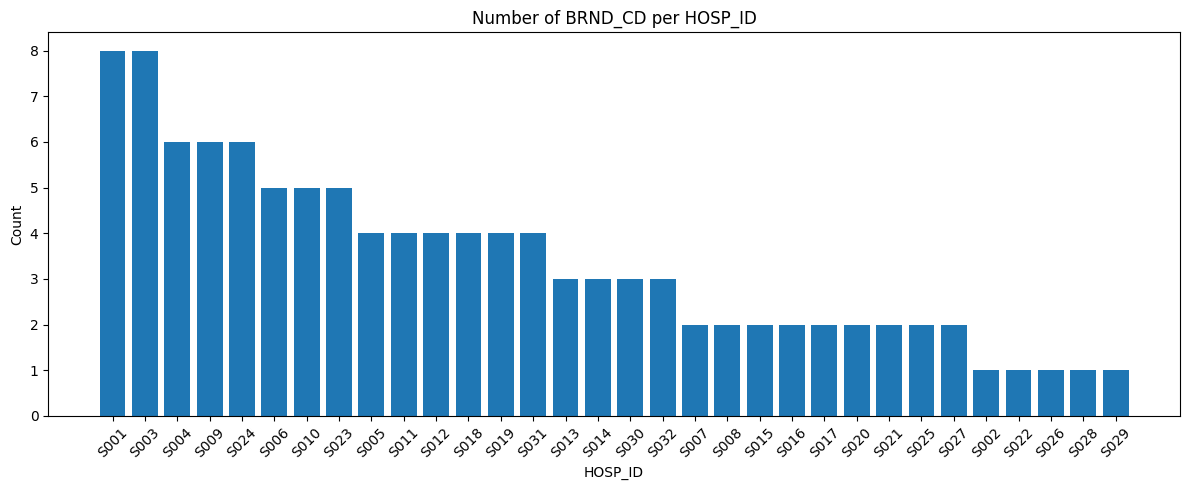

In [18]:
from collections import Counter
import matplotlib.pyplot as plt

hosp_counts = Counter(k.split('_')[0] for k in hosp_brnd_ver_dict.keys())
hosp_counts_sorted = dict(sorted(hosp_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(12, 5))
plt.bar(hosp_counts_sorted.keys(), hosp_counts_sorted.values())
plt.xlabel('HOSP_ID')
plt.ylabel('Count')
plt.title('Number of BRND_CD per HOSP_ID')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
brnd_ver_dict = brnd_cd_y_c1.groupby('BRND_CD')['BRND_NM_VER'].apply(lambda x: list(set(x))).to_dict()

In [20]:
brnd_ver_dict

{'P001': ['AlphaLiquid®100(v2)'],
 'P002': ['AUH-SCT1'],
 'P003': ['CancerSCAN compact'],
 'P004': ['FoundationOne CDx'],
 'P005': ['FoundationOne Liquid CDx'],
 'P006': ['NGS Pan cancer panel 525 ver.3'],
 'P007': ['Oncomine Comprehensive Assay Plus'],
 'P008': ['Oncomine Comprehensive Assay v3'],
 'P009': ['OncoPanel AMC v4.5'],
 'P010': ['Pan100 panel v2'],
 'P011': ['SNUBH Pan_Cancer Ver1'],
 'P012': ['SNUBH Pan_Cancer Ver2'],
 'P013': ['Solid Tumor Panel II(TMB/MSI)(RNA included)'],
 'P014': ['SOLIDaccuTest CNV SCH (v1.6)'],
 'P016': ['TSO500 ver2.2'],
 'P017': ['CancerSCAN v2.2'],
 'P018': ['ONCOaccuPanel v4.3'],
 'P019': ['ONCOaccuPanel v4.5'],
 'P020': ['CancerSCAN Level.2'],
 'P021': ['ACP1-KU'],
 'P022': ['K-MASTER PANEL V1.1'],
 'P023': ['Illumina TruSight Oncology 500 ctDNA'],
 'P024': ['ONCOaccuPanel v1.0'],
 'P025': ['Solid Tumor Panel II(TMB/MSI)(RNA not included)'],
 'P026': ['NGS Pan cancer panel 104 ver.2'],
 'P027': ['BrainTumorSCAN v2'],
 'P028': ['CancerSCAN v2.1']

In [21]:
brnd_cd_y_c2[brnd_cd_y_c2['BRND_NM_ECT_CMNT'].isna()]

,hosp_brnd_cd,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT
552,S009_P023,S009,S009-025,P023,NaN,NaN,NaN
921,S025_P001,S025,S025-009,P001,NaN,NaN,NaN


In [22]:
brnd_cd_y_c2[brnd_cd_y_c2['BRND_NM_ECT_CMNT'].notna()]

,hosp_brnd_cd,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT
57,S001_P016,S001,S001-002,P016,NaN,1.0,TSO500 ver2.2
59,S001_P016,S001,S001-028,P016,NaN,1.0,TSO500 ver2.2
60,S001_P016,S001,S001-027,P016,NaN,1.0,TSO500 ver2.2
61,S001_P012,S001,S001-026,P012,NaN,1.0,SNUBH Pan_Cancer Ver2
62,S001_P016,S001,S001-025,P016,NaN,1.0,TSO500 ver2.2
...,...,...,...,...,...,...,...
927,S025_P007,S025,S025-001,P007,NaN,1.0,Oncomine Comprehensive Assay Plus
950,S027_P007,S027,S027-003,P007,NaN,1.0,Oncomine Comprehensive Assay Plus
951,S027_P008,S027,S027-002,P008,NaN,1.0,Oncomine Comprehensive Assay v3
952,S027_P009,S027,S027-001,P009,NaN,1.0,OncoPanel AMC v4.5


In [23]:
brnd_cd_y_c2_v1 = brnd_cd_y_c2[brnd_cd_y_c2['BRND_NM_ECT_CMNT'].notna()]
brnd_cd_y_c2_v2 = brnd_cd_y_c2[brnd_cd_y_c2['BRND_NM_ECT_CMNT'].isna()]

hosp_brnd_cmnt_dict = brnd_cd_y_c2_v1.groupby(['HOSP_ID', 'BRND_CD'])['BRND_NM_ECT_CMNT'].apply(lambda x: list(set(x))).to_dict()
hosp_brnd_cmnt_dict = {f"{k[0]}_{k[1]}": v for k, v in hosp_brnd_cmnt_dict.items()}

In [24]:
hosp_brnd_cmnt_dict

{'S001_P012': ['SNUBH Pan_Cancer Ver2'],
 'S001_P016': ['TSO500 ver2.2'],
 'S002_P007': ['Oncomine Comprehensive Assay Plus'],
 'S003_P016': ['TSO500 ver2.2'],
 'S003_P017': ['CancerSCAN v2.2'],
 'S003_P034': ['CancerSCAN v3.1'],
 'S004_P016': ['TSO500 ver2.2'],
 'S004_P017': ['CancerSCAN v2.2'],
 'S005_P009': ['OncoPanel AMC v4.5'],
 'S005_P013': ['Solid Tumor Panel II(TMB/MSI)(RNA included)'],
 'S005_P016': ['TSO500 ver2.2'],
 'S006_P009': ['OncoPanel AMC v4.5'],
 'S006_P016': ['TSO500 ver2.2'],
 'S006_P032': ['OncoPanel AMC v4.3'],
 'S007_P007': ['Oncomine Comprehensive Assay Plus'],
 'S009_P003': ['CancerSCAN compact'],
 'S009_P034': ['CancerSCAN v3.1'],
 'S010_P015': ['TruSight Tumor 170 panel'],
 'S010_P016': ['TSO500 ver2.2'],
 'S011_P016': ['TSO500 ver2.2'],
 'S012_P007': ['Oncomine Comprehensive Assay Plus'],
 'S013_P013': ['Solid Tumor Panel II(TMB/MSI)(RNA included)'],
 'S016_P016': ['TSO500 ver2.2'],
 'S018_P018': ['ONCOaccuPanel v4.3'],
 'S020_P007': ['Oncomine Comprehensi

In [25]:
for key, values in hosp_brnd_cmnt_dict.items():
    brnd_cd = key.split('_')[1]
    if brnd_cd in brnd_ver_dict:
        standard = brnd_ver_dict[brnd_cd][0]
        for v in values:
            if v != standard:
                print(f"{key}: '{v}' != '{standard}'")

In [26]:
brnd_cd_y_c2_v1[(brnd_cd_y_c2_v1['hosp_brnd_cd'] == 'S020_P007') & (brnd_cd_y_c2_v1['BRND_NM_ECT_CMNT'] == 'Oncomine Comprehensive Assay plus')]

,hosp_brnd_cd,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT


In [27]:
#brnd_cd_n['BRND_NM_ECT_CMNT'].value_count()

In [28]:
brnd_cd_n[brnd_cd_n['BRND_NM_VER'].notna()]

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT
148,S002,S002-033,NaN,FIRST-Lung Cancer Panel v3.1,NaN,NaN
167,S002,S002-032,NaN,FIRST-Cancer Panel v3.3,NaN,NaN
169,S002,S002-029,NaN,FIRST-Cancer Panel v3.3,NaN,NaN
170,S002,S002-028,NaN,FIRST-Cancer Panel v3.3,NaN,NaN


In [29]:
brnd_cd_n[brnd_cd_n['BRND_NM_VER'].isna()]

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT
51,S001,S001-099,NaN,NaN,1.0,S001-098_panel
52,S001,S001-098,NaN,NaN,1.0,S001-098_panel
105,S001,S001-041,NaN,NaN,1.0,S001-041_panel
112,S001,S001-033,NaN,NaN,1.0,S001-033_panel
115,S002,S002-047,NaN,NaN,1.0,FIRST-Cancer Panel v3.3
...,...,...,...,...,...,...
931,S026,S026-005,NaN,NaN,1.0,"S026-005, S026-006, S026-007_panel"
932,S026,S026-007,NaN,NaN,1.0,"S026-005, S026-006, S026-007_panel"
982,S031,S031-023,NaN,NaN,1.0,S031-023_panel
990,S031,S031-014,NaN,NaN,1.0,FIRST-Cancer Panel v3.3


In [30]:
brnd_cd_n_c1 = brnd_cd_n[brnd_cd_n['BRND_NM_VER'].isna()]
brnd_cd_n_c2 =brnd_cd_n[brnd_cd_n['BRND_NM_VER'].notna()]

In [31]:
brnd_cd_n_c2

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT
148,S002,S002-033,NaN,FIRST-Lung Cancer Panel v3.1,NaN,NaN
167,S002,S002-032,NaN,FIRST-Cancer Panel v3.3,NaN,NaN
169,S002,S002-029,NaN,FIRST-Cancer Panel v3.3,NaN,NaN
170,S002,S002-028,NaN,FIRST-Cancer Panel v3.3,NaN,NaN


In [32]:
for idx, row in brnd_cd_n_c2.iterrows():
    ver = row['BRND_NM_VER']
    for key, values in brnd_ver_dict.items():
        if ver in values:
            print(f"idx {idx}: SUBJ_ID={row['SUBJ_ID']}, BRND_NM_VER='{ver}' -> {key}")

In [33]:
brnd_cd_n_c1['BRND_NM_ECT_CMNT'].value_counts()

BRND_NM_ECT_CMNT
FIRST-Cancer Panel v4.0                                   31
FIRST-Cancer Panel v3.3                                    9
S007(OCA)_panel                                            7
FIRST-Lung Cancer Panel v3.3                               5
FIRST-Brain Tumor Panel v3.3                               5
INOCRAS WGS report                                         3
S026-005, S026-006, S026-007_panel                         3
S019(OCA)_panel                                            3
FIRST-Brain Tumor Panel v3.0                               3
Cell-free cancer gene panel                                2
S009-011, S009-013_panel                                   2
JJY999                                                     2
S001-098_panel                                             2
FIRST-Cancer Panel v3.2                                    2
S003-083_panel                                             1
S031-023_panel                                             1
S001-03

In [34]:
for idx, row in brnd_cd_n_c1.iterrows():
    cmnt = row['BRND_NM_ECT_CMNT']
    if pd.notna(cmnt):
        for key, values in brnd_ver_dict.items():
            if cmnt in values:
                print(f"idx {idx}: SUBJ_ID={row['SUBJ_ID']}, BRND_NM_ECT_CMNT='{cmnt}' -> {key}")

In [35]:
brnd_cd_n_c1[brnd_cd_n_c1['SUBJ_ID'].isin(['S001-022', 'S007-016', 'S017-008'])]

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT
531,S007,S007-016,NaN,NaN,1.0,S007(OCA)_panel
